<a href="https://colab.research.google.com/github/clarissachng/ClarissaChngSiEn_COMS30045_IndividualProject/blob/main/3_initial_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pickle
from google.colab import drive
drive.mount('/content/drive')

with open("/content/drive/MyDrive/dataset/llm_rankings.pkl", "rb") as f:
    llm_results = pickle.load(f)

with open("/content/drive/MyDrive/dataset/nlp_rankings.pkl", "rb") as f:
    nlp_results = pickle.load(f)

print("LLM emotions:", list(llm_results["emotion"].keys()))
print("LLM tastes:  ", list(llm_results["taste"].keys()))
print("NLP emotions:", list(nlp_results["emotion"].keys()))
print("NLP tastes:  ", list(nlp_results["taste"].keys()))

Mounted at /content/drive
LLM emotions: ['happy', 'pleasure', 'astonished', 'relaxed', 'satisfied', 'tired', 'fear', 'angry', 'annoyed', 'sad', 'disgust', 'droopy']
LLM tastes:   ['sweet', 'sour', 'salty', 'bitter', 'umami']
NLP emotions: ['happy', 'pleasure', 'asthonished', 'relaxed', 'satisfied', 'tired', 'fear', 'angry', 'annoyed', 'sad', 'disgust', 'droopy']
NLP tastes:   ['sweet', 'sour', 'salty', 'bitter', 'umami']


In [2]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np

def compute_spearman(nlp_rankings, llm_rankings):
    """
    Aligns books common to both rankings,
    converts to rank positions, computes Spearman rho + p-value.
    """
    results = []

    for label in nlp_rankings:
        if label not in llm_rankings:
            print(f"  WARNING: '{label}' missing from LLM rankings — skipping")
            continue

        # Each ranking is [(filename, score), ...] sorted best first
        nlp_filenames = [fname for fname, _ in nlp_rankings[label]]
        llm_filenames = [fname for fname, _ in llm_rankings[label]]

        # Common books only
        common = [b for b in nlp_filenames if b in llm_filenames]

        if len(common) < 3:
            print(f"  WARNING: '{label}' has fewer than 3 common books — skipping")
            continue

        nlp_ranks = [nlp_filenames.index(b) + 1 for b in common]
        llm_ranks = [llm_filenames.index(b) + 1 for b in common]

        rho, pval = spearmanr(nlp_ranks, llm_ranks)

        results.append({
            "Label":        label,
            "Spearman ρ":   round(rho,  4),
            "p-value":      round(pval, 4),
            "Significant":  "✓" if pval < 0.05 else "✗",
            "N books":      len(common),
        })

    return pd.DataFrame(results).set_index("Label")


print("=" * 55)
print("EMOTION — NLP vs LLM Spearman Correlation")
print("=" * 55)
emotion_spearman = compute_spearman(nlp_results["emotion"], llm_results["emotion"])
print(emotion_spearman.to_string())

print("\n" + "=" * 55)
print("TASTE — NLP vs LLM Spearman Correlation")
print("=" * 55)
taste_spearman = compute_spearman(nlp_results["taste"], llm_results["taste"])
print(taste_spearman.to_string())

EMOTION — NLP vs LLM Spearman Correlation
           Spearman ρ  p-value Significant  N books
Label                                              
happy          0.9116      0.0           ✓    56185
pleasure       0.9432      0.0           ✓    56185
relaxed        0.9170      0.0           ✓    56185
satisfied      0.8678      0.0           ✓    56185
tired          0.7765      0.0           ✓    56185
fear           0.8787      0.0           ✓    56185
angry          0.8807      0.0           ✓    56185
annoyed        0.9211      0.0           ✓    56185
sad            0.9277      0.0           ✓    56185
disgust        0.8600      0.0           ✓    56185
droopy         0.9239      0.0           ✓    56185

TASTE — NLP vs LLM Spearman Correlation
        Spearman ρ  p-value Significant  N books
Label                                           
sweet       0.7507      0.0           ✓    56185
sour        0.9078      0.0           ✓    56185
salty       0.7605      0.0           ✓    56

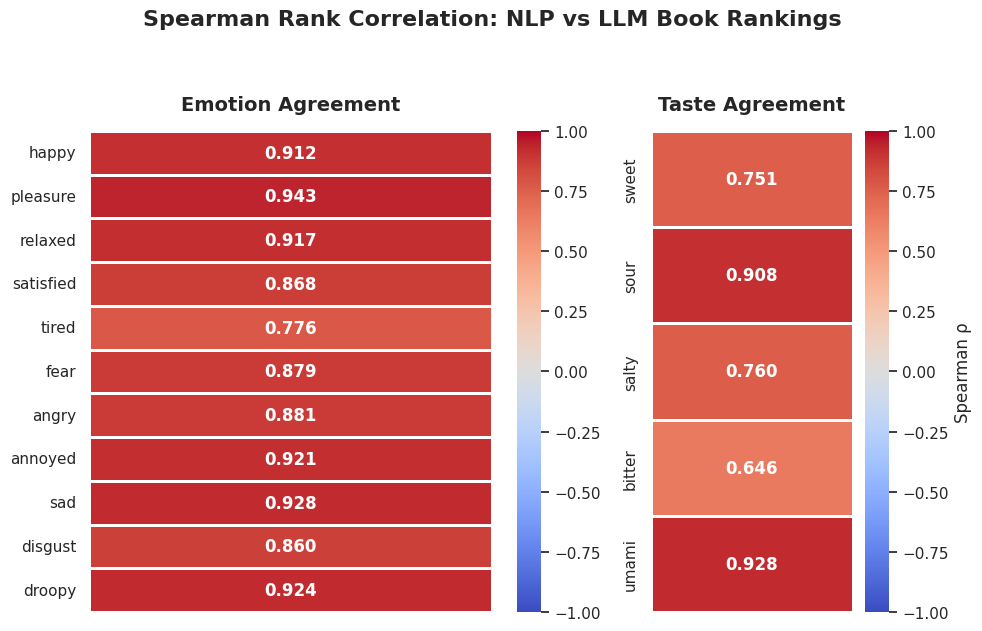

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style
sns.set_theme(style="white")

# Use width_ratios to make the boxes the same size in both plots
fig, axes = plt.subplots(1, 2, figsize=(10, 6),
                         gridspec_kw={'width_ratios': [1, 0.5]})

for ax, df, title in zip(axes,
                          [emotion_spearman, taste_spearman],
                          ["Emotion", "Taste"]):

    # Switch to vertical orientation for better label readability
    rho_vals = df[["Spearman ρ"]]

    sns.heatmap(rho_vals, ax=ax,
                annot=True, fmt=".3f", # 3 decimal places is cleaner for papers
                vmin=-1, vmax=1, center=0,
                cmap="coolwarm",
                linewidths=2, # Thicker lines look more modern
                linecolor='white',
                cbar_kws={"label": "Spearman ρ"} if ax == axes[1] else {"label": ""},
                annot_kws={"weight": "bold"})

    ax.set_title(f"{title} Agreement", fontweight="bold", fontsize=14, pad=15)
    ax.set_xlabel("")
    ax.set_ylabel("")
    # Remove the 'Spearman ρ' x-label for a cleaner look
    ax.set_xticks([])

plt.suptitle("Spearman Rank Correlation: NLP vs LLM Book Rankings",
             fontsize=16, fontweight="bold", y=1.05)

plt.tight_layout()
plt.show()

In [4]:
print("SUMMARY")
print("─" * 40)

for name, df in [("Emotion", emotion_spearman), ("Taste", taste_spearman)]:
    rhos = df["Spearman ρ"]
    sig  = (df["p-value"] < 0.05).sum()
    print(f"\n{name}:")
    print(f"  Mean ρ:        {rhos.mean():.4f}")
    print(f"  Max ρ:         {rhos.max():.4f}  ({rhos.idxmax()})")
    print(f"  Min ρ:         {rhos.min():.4f}  ({rhos.idxmin()})")
    print(f"  Significant:   {sig}/{len(df)} labels (p < 0.05)")

SUMMARY
────────────────────────────────────────

Emotion:
  Mean ρ:        0.8917
  Max ρ:         0.9432  (pleasure)
  Min ρ:         0.7765  (tired)
  Significant:   11/11 labels (p < 0.05)

Taste:
  Mean ρ:        0.7988
  Max ρ:         0.9283  (umami)
  Min ρ:         0.6465  (bitter)
  Significant:   5/5 labels (p < 0.05)
